In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

CSV_FILE = "Actual_consumption_202001010000_202601010000_Quarterhour.csv"

def smard_csv(file_path):
    # Semicolon separator, comma = thousands, dot = decimal
    df = pd.read_csv(file_path, sep=';', thousands=',', decimal='.', index_col=False)

    df['datetime'] = pd.to_datetime(df['Start date'])
    df = df.set_index('datetime') # to change 0, 1, 2, index in to date itself
    
    load_col = 'grid load [MWh] Original resolutions'
    df = df[[load_col]].rename(columns={load_col: 'load_mwh'}) 
    
    return df

df_load = smard_csv(CSV_FILE)

df = df_load

df = df.dropna()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour
df['is_weekend'] = df.index.weekday >= 5
df['day_of_year'] = df.index.dayofyear

print(f"Data processed: {df.index.min()} to {df.index.max()}")
df.tail()

/var/folders/hh/bg0bd4m54q5f6g46vd2jw09w0000gn/T/ipykernel_86228/4136758942.py:9: DtypeWarning: Columns (0: Residual load [MWh] Original resolutions) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep=';', thousands=',', decimal='.', index_col=False)
/var/folders/hh/bg0bd4m54q5f6g46vd2jw09w0000gn/T/ipykernel_86228/4136758942.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime'] = pd.to_datetime(df['Start date'])


Data processed: 2020-01-01 00:00:00 to 2025-12-31 23:45:00


,load_mwh,year,month,hour,is_weekend,day_of_year
datetime,,,,,,
2025-12-31 22:45:00,12092.33,2025,12,22,False,365
2025-12-31 23:00:00,11954.01,2025,12,23,False,365
2025-12-31 23:15:00,11905.14,2025,12,23,False,365
2025-12-31 23:30:00,11818.62,2025,12,23,False,365
2025-12-31 23:45:00,11756.82,2025,12,23,False,365


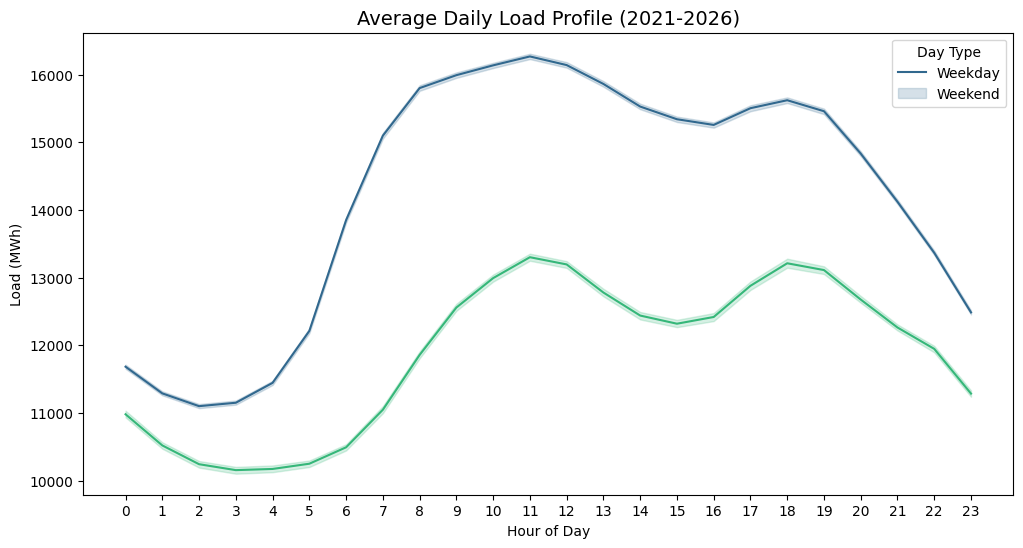

In [23]:
plt.figure(figsize=(12, 6))
df_recent = df[df['year'] >= 2021]

sns.lineplot(data=df_recent, x='hour', y='load_mwh', hue='is_weekend', palette="viridis")
plt.title("Average Daily Load Profile (2021-2026)", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Load (MWh)")
plt.xticks(range(24))
plt.legend(title="Day Type", labels=["Weekday", "Weekend"])
plt.show()

"""
4-8, climbing from ~11,100 MWh to ~15,800 MWh
Peak demand hits around hour 11 (11 AM) at approximately 16,500 MWh
Evening decline begins after hour 19, dropping sharply to ~12,600 MWh by hour 23
"""


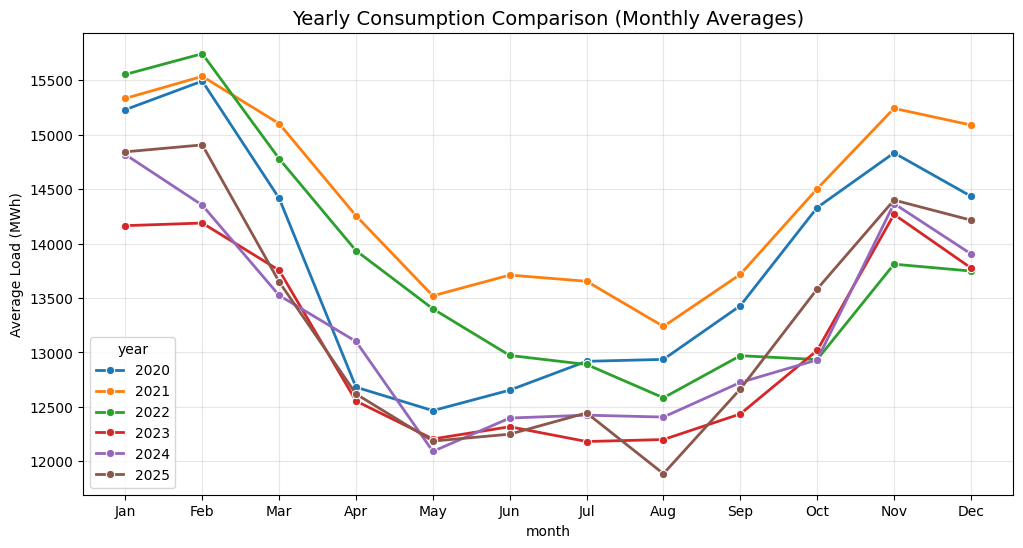

'\nEnergy use is highest in winter.\nIt drops sharply in spring.\nSummer has the lowest and most stable demand.\nConsumption rises again in autumn.\nBiggest jump = October and November.\n'

In [7]:
monthly = df[df['year'].between(2020, 2025)].groupby(['year', 'month'])['load_mwh'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x='month', y='load_mwh', hue='year', palette="tab10", marker='o', linewidth=2)
plt.title("Yearly Consumption Comparison (Monthly Averages)", fontsize=14)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel("Average Load (MWh)")
plt.grid(True, alpha=0.3)
plt.show()

'''
Energy use is highest in winter.
It drops sharply in spring.
Summer has the lowest and most stable demand.
Consumption rises again in autumn.
Biggest jump = October and November.
'''

In [9]:
def plot_holidays(df):
    holiday_days = df